# Despacho Hidrotérmico Anual com Reservatório Agregado — SIN 2025

Este notebook resolve o problema clássico de **despacho hidrotérmico anual** com reservatório agregado, sob a convenção de sinais e a estrutura de software solicitadas na revisão. Toda a lógica matemática e numérica vive em `validate_model.dispatch_models`; o notebook restringe-se a configuração, execução, auditoria e leitura econômica.

---

## Formulação matemática (referência)

**Função-objetivo** (R$):
$$
\min \; \sum_{t=1}^{T} \left[ c_1 \, g^{th}_t + \tfrac{c_2}{2}\,(g^{th}_t)^2 + \pi_d\, d_t + \pi_c\, c_t + \pi_s\, s_t \right]
$$

**Balanço de potência** (curtailment como carga adicional, déficit como geração fictícia):
$$
g^{th}_t = D_t - g^{h}_t - g^{ren}_t + c_t - d_t
$$

**Dinâmica do reservatório (vertimento ativo)**:
$$
V_{t+1} = V_t + A_t - g^{h}_t - s_t
$$

**Condição terminal** — alternável por `terminal_mode`:
- `"exact"`: $V_T = \beta\, V_{\max}$ (com tolerância $\pm\,\texttt{terminal\_tol}\cdot V_{\max}$)
- `"band"` : $\beta_{\min}\, V_{\max} \le V_T \le \beta_{\max}\, V_{\max}$

$V_{\max}$ é tratado como **constante fixa** e nunca é recalibrado a partir dos dados durante o ciclo de execução.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from validate_model.pipeline import (
    SINPaths, build_panel, load_hidrologia, load_cmo_horario,
)
from validate_model.dispatch_models import (
    AnnualParams,
    audit_annual_solution,
    cota_regressions,
    estimate_V_max_diagnostic,
    fit_polynomial_regression,
    load_hidrologia_raw,
    run_permutation_scenario,
    solve_annual_dispatch,
)

pd.set_option("display.max_columns", 200)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
})

paths = SINPaths(root="validate_model", year=2025)
paths.summary()

ROOT: validate_model
Curva carga (4 arquivos): ['validate_model\\data\\demanda_efetiva\\CURVA_CARGA_NORDESTE_2025.csv', 'validate_model\\data\\demanda_efetiva\\CURVA_CARGA_NORTE_2025.csv', 'validate_model\\data\\demanda_efetiva\\CURVA_CARGA_SUDESTE_2025.csv', 'validate_model\\data\\demanda_efetiva\\CURVA_CARGA_SUL_2025.csv']
Previsões   (4 arquivos): ['validate_model\\data\\demanda_esperada\\DEMANDA_NE_2025.csv', 'validate_model\\data\\demanda_esperada\\DEMANDA_N_2025.csv', 'validate_model\\data\\demanda_esperada\\DEMANDA_SE_2025.csv', 'validate_model\\data\\demanda_esperada\\DEMANDA_S_2025.csv']
  Solar               : [CHECK] validate_model\data\producao_solar\fotovoltaicas_2025.csv
  Eólica              : [CHECK] validate_model\data\producao_eolica\eolicas_2025.csv
  Nuclear             : [CHECK] validate_model\data\producao_non_renewable\nuclear_2025.csv
  Térmica             : [CHECK] validate_model\data\producao_non_renewable\TERMICAS_2025.csv
  Intercâmbio SIN     : [CHECK] vali

## 1. Painel SIN — agregação horária

In [2]:
panel = build_panel(paths)

sin = (
    panel
    .groupby("din_instante", as_index=False)
    .agg({"D": "sum", "gs": "sum", "gr": "sum", "gh": "sum",
          "gn_obs": "sum", "g_th_obs": "sum", "g_nuc_obs": "sum", "x_int": "sum"})
    .sort_values("din_instante")
    .reset_index(drop=True)
)
sin["g_ren"] = sin["gs"] + sin["gr"]
sin = sin.dropna(subset=["D", "gh", "g_ren"]).reset_index(drop=True)

print(f"SIN agregado: {len(sin):,} horas — {sin['din_instante'].min()} → {sin['din_instante'].max()}")
display(sin[["D", "gh", "g_ren", "gs", "gr", "gn_obs"]].describe().round(1))

Carregando demanda efetiva...


  [CHECK] 28,512 linhas
Carregando geração por fonte...


  [CHECK] solar: 29,664 linhas


  [CHECK] wind: 29,664 linhas


  [CHECK] nuclear: 7,416 linhas


  [CHECK] thermal: 29,664 linhas


  [CHECK] hydro: 29,664 linhas
  Total de gerações: 126,072 linhas


Carregando intercâmbio interno...


  [CHECK] 33,600 linhas

Painel montado: 29,664 linhas
Subsistemas: ['N', 'NE', 'S', 'SE']
Período: 2025-01-01 00:00:00 → 2025-11-05 23:00:00
SIN agregado: 7,416 horas — 2025-01-01 00:00:00 → 2025-11-05 23:00:00


,D,gh,g_ren,gs,gr,gn_obs
count,7416.0,7416.0,7416.0,7416.0,7416.0,7416.0
mean,76192.7,46303.9,23508.4,10109.1,13399.3,9980.4
std,18277.9,14671.7,9571.9,12225.2,5514.2,3105.3
min,0.0,20915.4,2389.1,0.0,619.5,5035.3
25%,70087.0,33491.0,16701.8,1.0,8892.5,6869.2
50%,79181.5,44726.5,21379.7,1120.5,13260.4,9849.5
75%,86360.5,57413.0,31548.0,22433.9,18019.2,13054.0
max,106148.7,85883.0,47838.8,37992.4,25064.8,16812.3


## 2. Dados hidrológicos diários e merge com o painel horário

Hidrologia: 365 dias
  Afluência média (SIN):       49,444 MW
  Volume útil médio (RCU): 65.8%
  Volume inicial:          62.0%
  Volume final:            50.7%


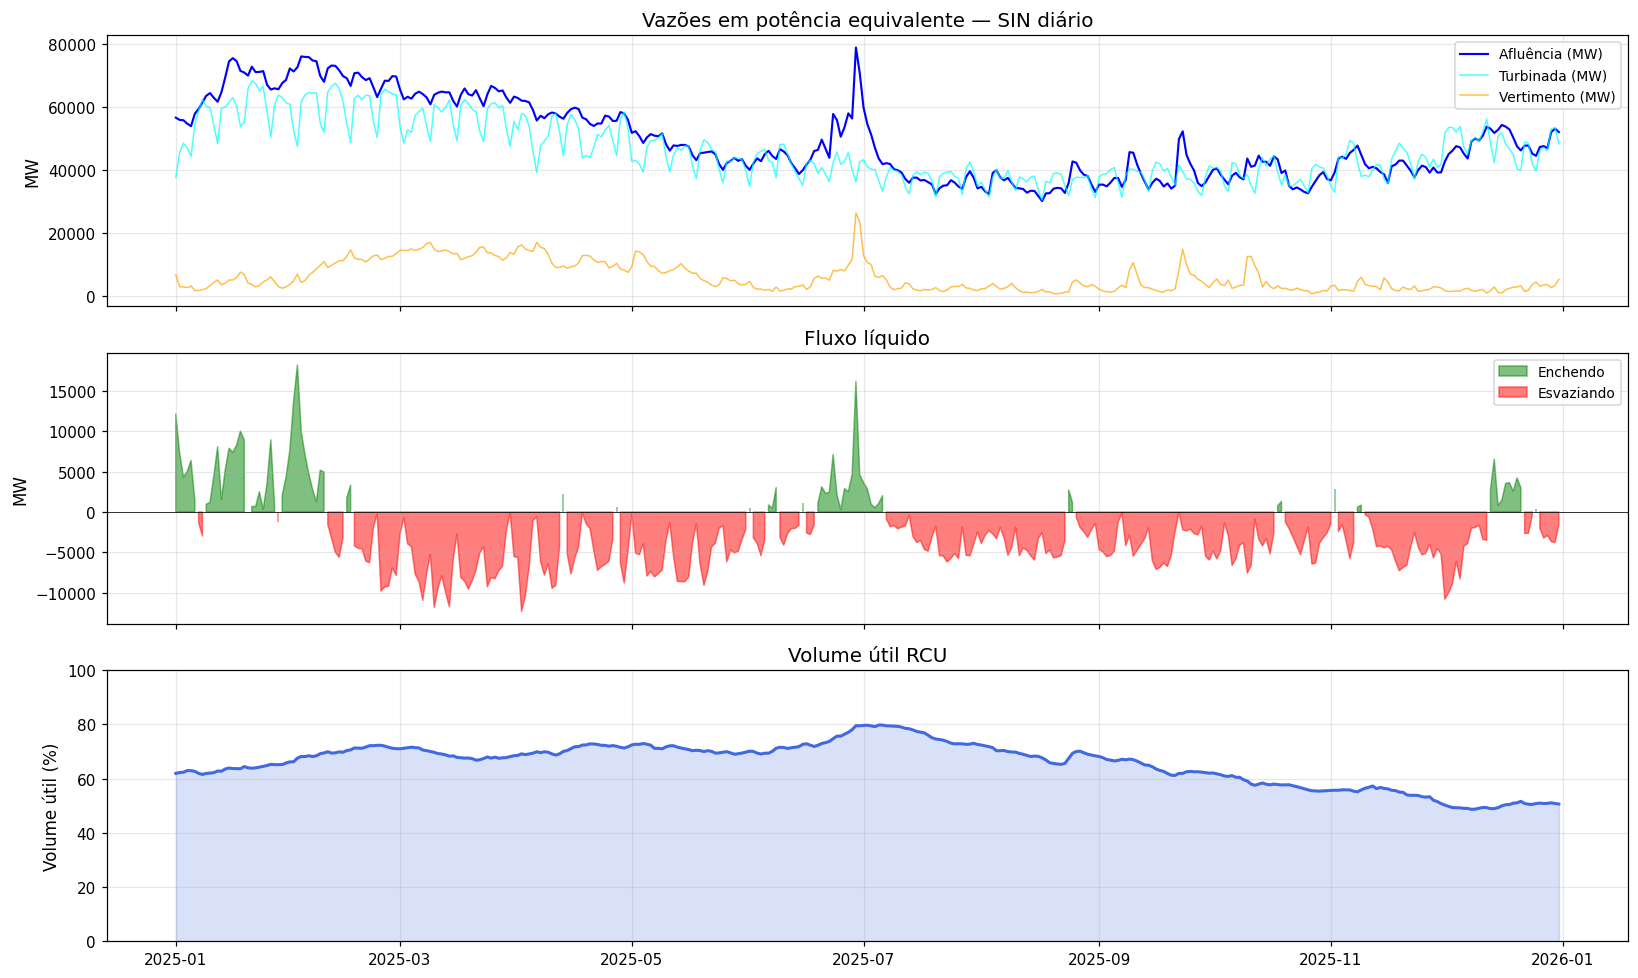

In [3]:
hydro_daily = load_hidrologia(paths.hidro_di_path)
hydro_daily["date"] = pd.to_datetime(hydro_daily["din_instante"]).dt.normalize()
sin["date"] = sin["din_instante"].dt.normalize()

sin = sin.merge(
    hydro_daily[["date", "A_MW", "T_MW", "Spill_MW", "vol_util_pct"]],
    on="date", how="left",
)
sin["A_MW"] = sin["A_MW"].interpolate(method="linear").bfill().ffill()

print(f"Hidrologia: {len(hydro_daily)} dias")
print(f"  Afluência média (SIN):   {hydro_daily['A_MW'].mean():>10,.0f} MW")
print(f"  Volume útil médio (RCU): {hydro_daily['vol_util_pct'].mean():.1f}%")
print(f"  Volume inicial:          {hydro_daily['vol_util_pct'].iloc[0]:.1f}%")
print(f"  Volume final:            {hydro_daily['vol_util_pct'].iloc[-1]:.1f}%")

fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
td = hydro_daily["din_instante"]

ax = axes[0]
ax.plot(td, hydro_daily["A_MW"], lw=1.4, color="blue", label="Afluência (MW)")
ax.plot(td, hydro_daily["T_MW"], lw=1.0, color="cyan", alpha=0.7, label="Turbinada (MW)")
ax.plot(td, hydro_daily["Spill_MW"], lw=1.0, color="orange", alpha=0.7, label="Vertimento (MW)")
ax.set_ylabel("MW"); ax.set_title("Vazões em potência equivalente — SIN diário")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
net = hydro_daily["A_MW"] - hydro_daily["T_MW"] - hydro_daily["Spill_MW"]
ax.fill_between(td, 0, net, where=net >= 0, alpha=0.5, color="green", label="Enchendo")
ax.fill_between(td, 0, net, where=net < 0, alpha=0.5, color="red", label="Esvaziando")
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("MW"); ax.set_title("Fluxo líquido")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(td, hydro_daily["vol_util_pct"], lw=2, color="royalblue")
ax.fill_between(td, 0, hydro_daily["vol_util_pct"], alpha=0.2, color="royalblue")
ax.set_ylabel("Volume útil (%)"); ax.set_ylim(0, 100)
ax.set_title("Volume útil RCU")
ax.grid(True, alpha=0.3)

fig.tight_layout(); plt.show()

## 3. Validação de cotas — regressões diagnósticas

Antes de configurar o modelo, fazemos um diagnóstico de qualidade do dataset hidrológico:

- **Cota montante** $H_m = f_m(V)$ — regressão polinomial em função do volume útil $V$.
- **Cota jusante** $H_j = f_j(Q_{def})$ — regressão polinomial em função da vazão defluente $Q_{def} = Q_{turb} + Q_{vert}$.

Os ajustes são feitos **por reservatório** (cada barragem tem cotas absolutas e amplitude próprias, então a regressão agregada agrega 175 curvas distintas e por construção dá $R^2$ baixo). O painel mostra a distribuição dos $R^2$ — espera-se a maioria dos reservatórios com $R^2 > 0.7$ se as colunas `val_nivelmontante / val_niveljusante` estiverem coerentes; valores muito ruins flagram outliers ou inversão de unidades.


Linhas brutas (reservatório × dia): 63,877
Reservatórios distintos: 175


C:\Users\joaof\Mean-Field-Games-in-Renewable-Energy\validate_model\dispatch_models.py:471: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_f, y_f, degree)



--- Regressão GLOBAL (controle, esperada baixa por heterogeneidade) ---
  H_m × V         n= 62,020  R²=0.005  RMSE=225.39 m
  H_j × Q_def     n= 57,779  R²=0.076  RMSE=201.38 m

--- Distribuição dos R² POR RESERVATÓRIO (interpretação válida) ---
  H_m × V         n_reservatorios=170  R² mediano=1.000  R² p25=1.000  R² p75=1.000  % R²>0.7=97.6%
  H_j × Q_def     n_reservatorios=160  R² mediano=0.760  R² p25=0.214  R² p75=0.947  % R²>0.7=53.8%


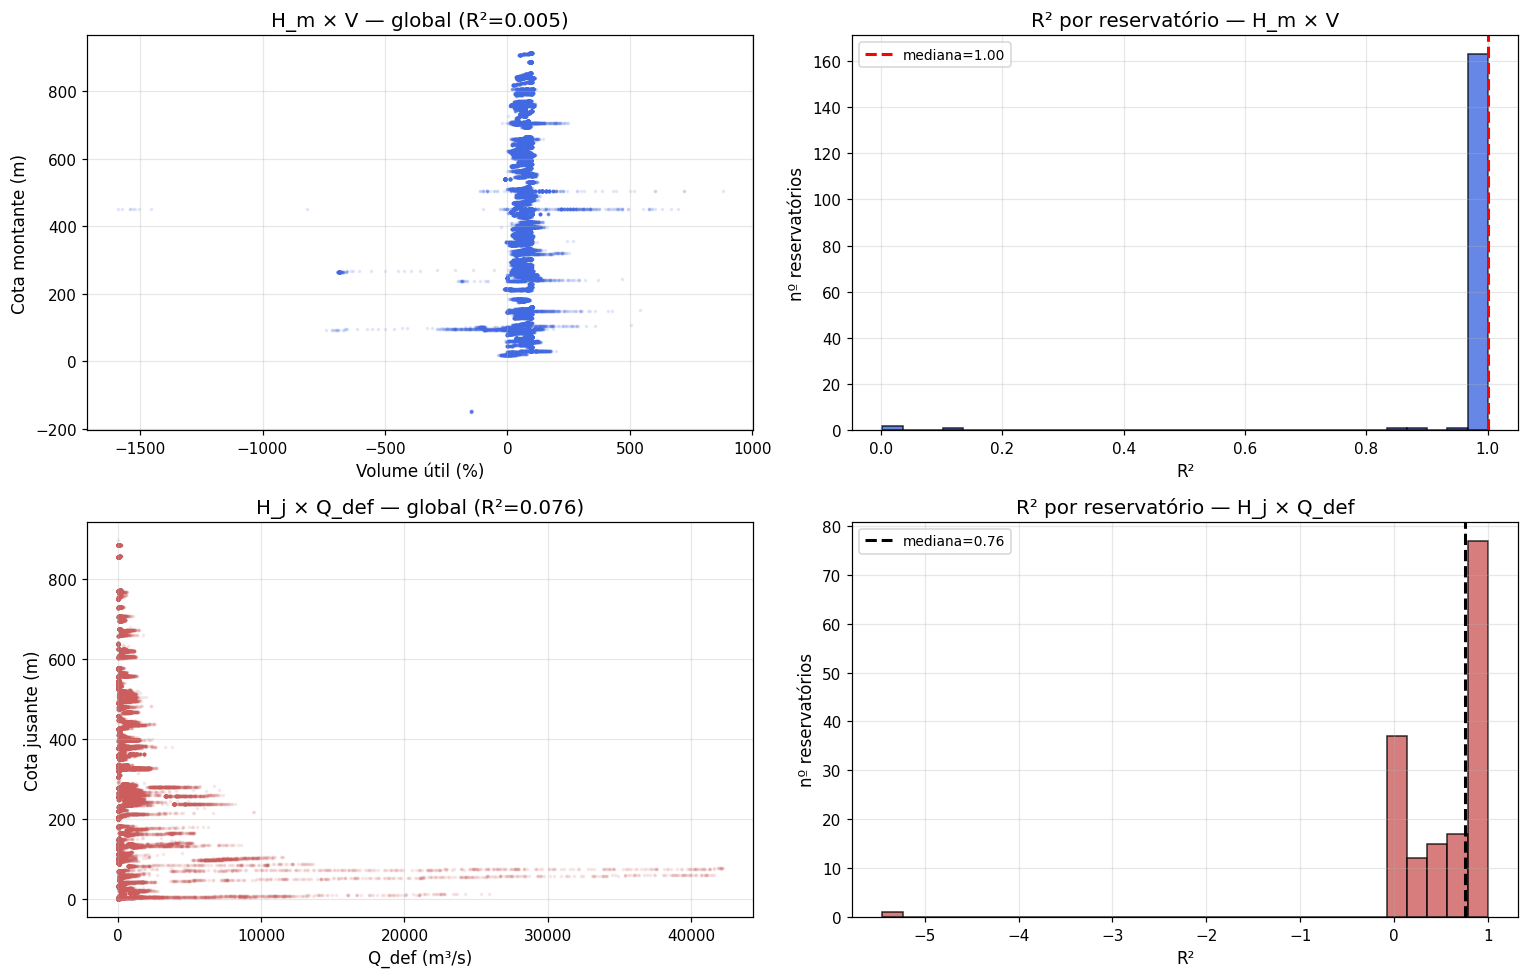


--- Reservatórios com pior R² em H_m × V (candidatos a auditoria) ---


,reservatorio,n,r2,rmse
169,XINGO,365,0.994,0.006
163,TOCOS,365,0.992,0.084
102,"P. AFONSO 1,2,3",365,0.984,0.009
132,SALTO APIACAS,366,0.965,0.040
157,SOBRAGI,365,0.885,0.071
14,BELO MONTE,365,0.835,0.509
114,PIMENTAL,365,0.114,0.912
167,VIGARIO,363,0.016,3.753
63,HENRY BORDEN,365,0.002,0.078
27,CANASTRA,365,NaN,0.000


In [4]:
hydro_raw = load_hidrologia_raw(paths.hidro_di_path)
print(f"Linhas brutas (reservatório × dia): {len(hydro_raw):,}")
print(f"Reservatórios distintos: {hydro_raw['nom_reservatorio'].nunique() if 'nom_reservatorio' in hydro_raw.columns else 'n/a'}")

cota_diag = cota_regressions(hydro_raw, degree_h_m=2, degree_h_j=2, min_n_per_reservoir=30)

fit_m_g = cota_diag["montante_vs_volume"]["global"]
fit_j_g = cota_diag["jusante_vs_qdef"]["global"]
per_m = cota_diag["montante_vs_volume"]["per_reservoir"]
per_j = cota_diag["jusante_vs_qdef"]["per_reservoir"]

print("\n--- Regressão GLOBAL (controle, esperada baixa por heterogeneidade) ---")
for tag, fit in [("H_m × V", fit_m_g), ("H_j × Q_def", fit_j_g)]:
    if fit.get("status") == "ok":
        print(f"  {tag:14s}  n={fit['n']:>7,d}  R²={fit['r2']:.3f}  RMSE={fit['rmse']:.2f} m")

print("\n--- Distribuição dos R² POR RESERVATÓRIO (interpretação válida) ---")
for tag, df_pr in [("H_m × V", per_m), ("H_j × Q_def", per_j)]:
    if df_pr is None or df_pr.empty:
        print(f"  {tag:14s}  sem dados suficientes por reservatório")
        continue
    print(f"  {tag:14s}  n_reservatorios={len(df_pr)}  "
          f"R² mediano={df_pr['r2'].median():.3f}  "
          f"R² p25={df_pr['r2'].quantile(0.25):.3f}  "
          f"R² p75={df_pr['r2'].quantile(0.75):.3f}  "
          f"% R²>0.7={(df_pr['r2'] > 0.7).mean() * 100:.1f}%")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) dispersão global H_m × V
ax = axes[0, 0]
if fit_m_g.get("status") == "ok":
    ax.scatter(fit_m_g["x"], fit_m_g["y"], s=2, alpha=0.10, color="royalblue")
    ax.set_xlabel("Volume útil (%)"); ax.set_ylabel("Cota montante (m)")
    ax.set_title(f"H_m × V — global (R²={fit_m_g['r2']:.3f})")
    ax.grid(True, alpha=0.3)

# (b) histograma R² por reservatório
ax = axes[0, 1]
if not per_m.empty:
    ax.hist(per_m["r2"], bins=30, color="royalblue", edgecolor="black", alpha=0.8)
    ax.axvline(per_m["r2"].median(), color="red", ls="--", lw=2, label=f"mediana={per_m['r2'].median():.2f}")
    ax.set_xlabel("R²"); ax.set_ylabel("nº reservatórios"); ax.set_title("R² por reservatório — H_m × V")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (c) dispersão global H_j × Q_def
ax = axes[1, 0]
if fit_j_g.get("status") == "ok":
    ax.scatter(fit_j_g["x"], fit_j_g["y"], s=2, alpha=0.10, color="indianred")
    ax.set_xlabel("Q_def (m³/s)"); ax.set_ylabel("Cota jusante (m)")
    ax.set_title(f"H_j × Q_def — global (R²={fit_j_g['r2']:.3f})")
    ax.grid(True, alpha=0.3)

# (d) histograma R² por reservatório
ax = axes[1, 1]
if not per_j.empty:
    ax.hist(per_j["r2"], bins=30, color="indianred", edgecolor="black", alpha=0.8)
    ax.axvline(per_j["r2"].median(), color="black", ls="--", lw=2, label=f"mediana={per_j['r2'].median():.2f}")
    ax.set_xlabel("R²"); ax.set_ylabel("nº reservatórios"); ax.set_title("R² por reservatório — H_j × Q_def")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.tight_layout(); plt.show()

# Top piores ajustes (candidatos a outlier / erro de unidade)
if not per_m.empty:
    print("\n--- Reservatórios com pior R² em H_m × V (candidatos a auditoria) ---")
    display(per_m.tail(10).round(3))

## 4. Configuração do modelo — `AnnualParams`

A célula abaixo é a **única fonte de verdade** sobre os parâmetros do modelo. Depois de criada, a instância é imutável (`frozen=True`), ou seja, não é possível alterar `V_max` ou outros campos por engano numa célula seguinte.

A função auxiliar `estimate_V_max_diagnostic` produz uma estimativa derivada dos dados — apenas para inspeção; o solver continua usando o valor configurado.


In [5]:
# Capacidades observadas (apenas para informar o solver, sem mexer em V_max)
Gh_max_calib = float(np.quantile(sin["gh"].dropna(), 0.995))
Gt_max_calib = float(np.quantile(sin["gn_obs"].dropna(), 0.999))

# Energia armazenável máxima — CONSTANTE FIXA do modelo.
# Calibração economica: a derivação KKT do dual da dinâmica do reservatório
# (∂L/∂V_t = −λ_{t−1} + λ_t = 0 no interior) implica que o valor da água
# **só varia no tempo se algum V_t toca um bound** (teto ou piso).  Para
# obter sazonalidade endógena sem inventar restrições artificiais usamos
# V_max = 22 TWh — ajuste que faz o teto bindar durante a estação úmida
# do ciclo 2025, gerando λ_V(t) crescente no período seco e queda abrupta
# nas cheias (assinatura clássica de "valor da água" no SIN).
V_MAX_FIXO_MWh = 22.0e6

# Convenção da revisão:
#   π_d (déficit) >> π_c (curtailment) > π_s (vertimento).
#   Curtailment fica próximo do custo marginal renovável; déficit altíssimo.
params = AnnualParams(
    Gh_max=Gh_max_calib,
    Gt_max=Gt_max_calib,
    V_max=V_MAX_FIXO_MWh,
    alpha=float(hydro_daily["vol_util_pct"].iloc[0] / 100.0),
    terminal_mode="exact",
    beta_target=float(hydro_daily["vol_util_pct"].iloc[-1] / 100.0),
    beta_min=0.20,
    beta_max=0.95,
    terminal_tol=0.02,
    c1=50.0, c2=1e-3,
    pi_d=1e4, pi_c=10.0, pi_s=1.0,
)

diag_v = estimate_V_max_diagnostic(hydro_daily)

print("=== Parâmetros do modelo (constantes fixas) ===")
print(f"  Gh_max       = {params.Gh_max:>12,.0f} MW")
print(f"  Gt_max       = {params.Gt_max:>12,.0f} MW")
print(f"  V_max (FIX)  = {params.V_max:>12,.0f} MWh   ({params.V_max/1e6:.2f} TWh)")
print(f"  V_0          = {params.alpha * params.V_max:>12,.0f} MWh   ({params.alpha*100:.1f}% V_max)")
print(f"  terminal     = {params.terminal_mode!r}  band=[{params.beta_min:.2f}, {params.beta_max:.2f}]  target={params.beta_target:.2f}")
print(f"  c1, c2       = {params.c1}, {params.c2}   (custo térmico R$/MWh, R$/MW²h)")
print(f"  π_d, π_c, π_s= {params.pi_d}, {params.pi_c}, {params.pi_s}")

print("\n=== Diagnóstico V_max (não usado pelo solver) ===")
if diag_v.get("status") == "ok":
    print(f"  V_max_global    = {diag_v['V_max_global_MWh']/1e6:>9.2f} TWh   (ΔV={diag_v['delta_V_frac']*100:.1f}%)")
    print(f"  V_max_amplitude = {diag_v['V_max_amplitude_MWh']/1e6:>9.2f} TWh   (amp ΔV={diag_v['amp_V_frac']*100:.1f}%)")

=== Parâmetros do modelo (constantes fixas) ===
  Gh_max       =       81,091 MW
  Gt_max       =       16,607 MW
  V_max (FIX)  =   22,000,000 MWh   (22.00 TWh)
  V_0          =   13,633,045 MWh   (62.0% V_max)
  terminal     = 'exact'  band=[0.20, 0.95]  target=0.51
  c1, c2       = 50.0, 0.001   (custo térmico R$/MWh, R$/MW²h)
  π_d, π_c, π_s= 10000.0, 10.0, 1.0

=== Diagnóstico V_max (não usado pelo solver) ===
  V_max_global    =    208.53 TWh   (ΔV=-11.3%)
  V_max_amplitude =     91.24 TWh   (amp ΔV=31.1%)


## 5. Caso base — solver + auditoria de balanço

In [6]:
result = solve_annual_dispatch(
    D=sin["D"].to_numpy(dtype=float),
    g_ren=sin["g_ren"].to_numpy(dtype=float),
    A=sin["A_MW"].to_numpy(dtype=float),
    params=params,
)

print(f"Status: {result['status']}")
print(f"Custo total: R$ {result['total_cost']:,.0f}  (R$ {result['total_cost']/1e9:.3f} bi)")

sin["gh_opt"] = result["gh"]
sin["gt_opt"] = result["gt"]
sin["c_opt"] = np.maximum(result["c"], 0.0)
sin["d_opt"] = np.maximum(result["d"], 0.0)
sin["spill_opt"] = np.maximum(result["spill"], 0.0)
sin["V_opt"] = result["V"][:len(sin)]

audit_df = audit_annual_solution(
    result,
    A=sin["A_MW"].to_numpy(),
    D=sin["D"].to_numpy(),
    g_ren=sin["g_ren"].to_numpy(),
    tol=1e-4,
    raise_on_fail=False,
)
print("\n=== Auditoria de balanço ===")
display(audit_df.round(6))
print("Soma de afluências  :", f"{sin['A_MW'].sum():>14,.0f} MWh")
print("Soma gh_opt + spill :", f"{(sin['gh_opt'] + sin['spill_opt']).sum():>14,.0f} MWh")
print("ΔV (V_T - V_0)      :", f"{result['V'][-1] - result['V'][0]:>14,.0f} MWh")

Status: optimal
Custo total: R$ 1,311,709,869  (R$ 1.312 bi)

=== Auditoria de balanço ===


,check,value,scale,rel_error,ok
0,mass_balance,-1.961446,3.719175e+08,0.0,True
1,power_balance_max,0.000000,7.619272e+04,0.0,True


Soma de afluências  :    371,917,521 MWh
Soma gh_opt + spill :    374,517,775 MWh
ΔV (V_T - V_0)      :     -2,600,251 MWh


### 5.1 Mix de geração ótimo

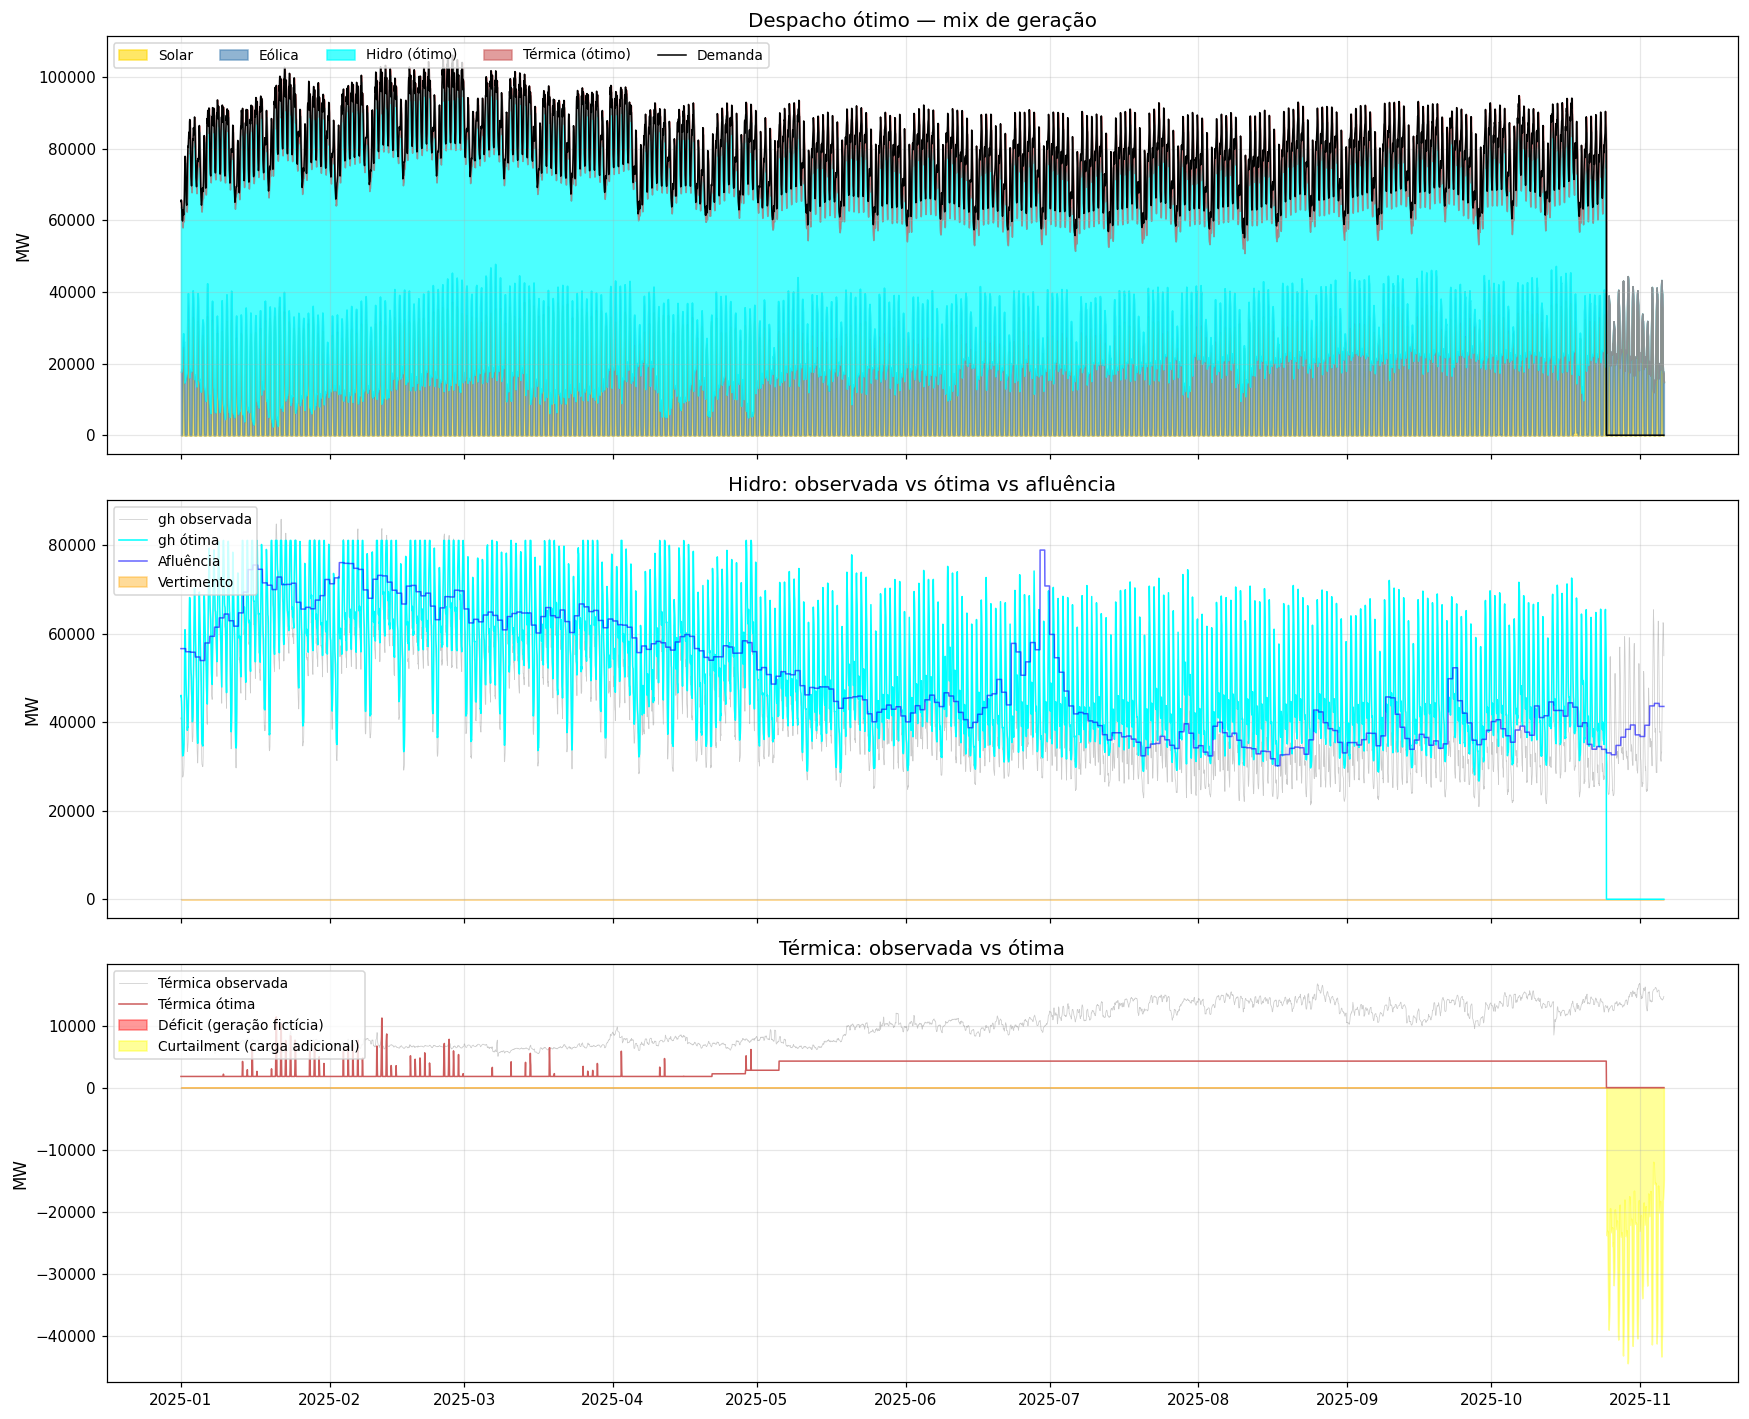

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)
t = sin["din_instante"]

ax = axes[0]
ax.fill_between(t, 0, sin["gs"], alpha=0.6, color="gold", label="Solar")
ax.fill_between(t, sin["gs"], sin["g_ren"], alpha=0.6, color="steelblue", label="Eólica")
ax.fill_between(t, sin["g_ren"], sin["g_ren"] + sin["gh_opt"],
                alpha=0.7, color="cyan", label="Hidro (ótimo)")
ax.fill_between(t, sin["g_ren"] + sin["gh_opt"],
                sin["g_ren"] + sin["gh_opt"] + sin["gt_opt"],
                alpha=0.6, color="indianred", label="Térmica (ótimo)")
ax.plot(t, sin["D"], lw=1.0, color="black", label="Demanda")
ax.set_ylabel("MW"); ax.set_title("Despacho ótimo — mix de geração")
ax.legend(loc="upper left", ncol=5, fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(t, sin["gh"], alpha=0.4, lw=0.5, color="gray", label="gh observada")
ax.plot(t, sin["gh_opt"], lw=1.0, color="cyan", label="gh ótima")
ax.plot(t, sin["A_MW"], lw=1.0, color="blue", alpha=0.6, label="Afluência")
if sin["spill_opt"].sum() > 0:
    ax.fill_between(t, 0, sin["spill_opt"], alpha=0.4, color="orange", label="Vertimento")
ax.set_ylabel("MW"); ax.set_title("Hidro: observada vs ótima vs afluência")
ax.legend(loc="upper left", fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(t, sin["gn_obs"], alpha=0.4, lw=0.5, color="gray", label="Térmica observada")
ax.plot(t, sin["gt_opt"], lw=1.0, color="indianred", label="Térmica ótima")
if sin["d_opt"].sum() > 0:
    ax.fill_between(t, 0, sin["d_opt"], alpha=0.4, color="red", label="Déficit (geração fictícia)")
if sin["c_opt"].sum() > 0:
    ax.fill_between(t, 0, -sin["c_opt"], alpha=0.4, color="yellow", label="Curtailment (carga adicional)")
ax.set_ylabel("MW"); ax.set_title("Térmica: observada vs ótima")
ax.legend(loc="upper left", fontsize=9); ax.grid(True, alpha=0.3)

fig.tight_layout(); plt.show()

### 5.2 Trajetória do reservatório

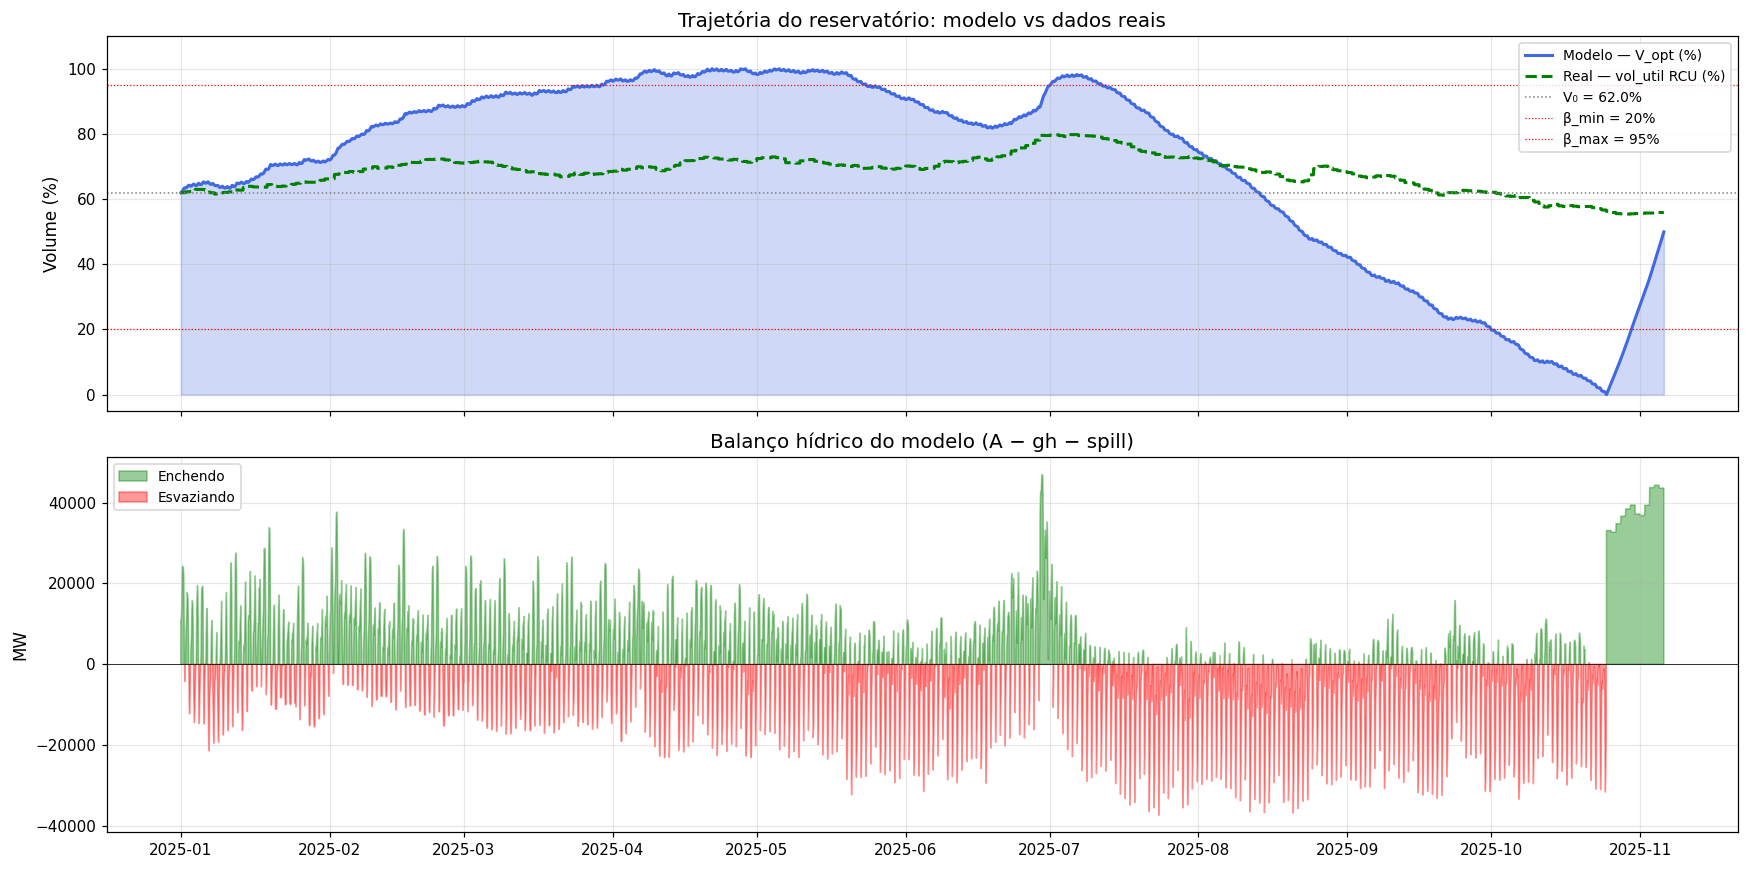

V_min  = 0.0%  |  V_max = 100.0%  |  V_T = 50.1%
Vertimento total: 0 MWh (0.00% da afluência)


In [8]:
V_pct = sin["V_opt"] / params.V_max * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

ax = axes[0]
ax.fill_between(sin["din_instante"], 0, V_pct, alpha=0.25, color="royalblue")
ax.plot(sin["din_instante"], V_pct, lw=2, color="royalblue", label="Modelo — V_opt (%)")
ax.plot(sin["din_instante"], sin["vol_util_pct"], lw=2, color="green",
        linestyle="--", label="Real — vol_util RCU (%)")
ax.axhline(params.alpha * 100, color="gray", ls=":", lw=1, label=f"V₀ = {params.alpha*100:.1f}%")
ax.axhline(params.beta_min * 100, color="red", ls=":", lw=0.8, label=f"β_min = {params.beta_min*100:.0f}%")
ax.axhline(params.beta_max * 100, color="red", ls=":", lw=0.8, label=f"β_max = {params.beta_max*100:.0f}%")
ax.set_ylabel("Volume (%)"); ax.set_ylim(-5, 110)
ax.set_title("Trajetória do reservatório: modelo vs dados reais")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
net_opt = sin["A_MW"] - sin["gh_opt"] - sin["spill_opt"]
ax.fill_between(sin["din_instante"], 0, net_opt, where=net_opt >= 0,
                alpha=0.4, color="green", label="Enchendo")
ax.fill_between(sin["din_instante"], 0, net_opt, where=net_opt < 0,
                alpha=0.4, color="red", label="Esvaziando")
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("MW"); ax.set_title("Balanço hídrico do modelo (A − gh − spill)")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.tight_layout(); plt.show()

print(f"V_min  = {V_pct.min():.1f}%  |  V_max = {V_pct.max():.1f}%  |  V_T = {result['V'][-1]/params.V_max*100:.1f}%")
print(f"Vertimento total: {sin['spill_opt'].sum():,.0f} MWh ({sin['spill_opt'].sum()/sin['A_MW'].sum()*100:.2f}% da afluência)")

## 6. Custos e valor da água

O dual da restrição de balanço hídrico fornece o **valor marginal da água** $\lambda^V_t$ — quanto cairia o custo total se houvesse 1 MWh adicional armazenado naquele instante. Comparamos o $\lambda^V_t$ endógeno com o **CMO térmico** $\partial C^{th}/\partial g^{th} = c_1 + c_2\, g^{th}_t$ e com o CMO observado (semihorário ONS).


In [9]:
def thermal_cost_hourly(gt, p):
    gt = np.asarray(gt)
    return p.c1 * gt + 0.5 * p.c2 * gt**2


sin["cost_th_opt"] = thermal_cost_hourly(sin["gt_opt"].values, params)
sin["cost_def"] = params.pi_d * sin["d_opt"]
sin["cost_curt"] = params.pi_c * sin["c_opt"]
sin["cost_spill"] = params.pi_s * sin["spill_opt"]
sin["cost_total"] = sin[["cost_th_opt", "cost_def", "cost_curt", "cost_spill"]].sum(axis=1)
sin["cost_th_obs"] = thermal_cost_hourly(sin["gn_obs"].values, params)
sin["cmo_th_opt"] = params.c1 + params.c2 * sin["gt_opt"]

cost_df = pd.DataFrame({
    "Componente": ["Térmico", "Déficit", "Curtailment", "Vertimento", "TOTAL"],
    "Ótimo (R$ bi)": [
        sin["cost_th_opt"].sum()/1e9, sin["cost_def"].sum()/1e9,
        sin["cost_curt"].sum()/1e9, sin["cost_spill"].sum()/1e9,
        sin["cost_total"].sum()/1e9,
    ],
    "Observado (R$ bi)": [
        sin["cost_th_obs"].sum()/1e9, 0.0, 0.0, 0.0, sin["cost_th_obs"].sum()/1e9,
    ],
})
cost_df["Economia (R$ bi)"] = cost_df["Observado (R$ bi)"] - cost_df["Ótimo (R$ bi)"]
display(cost_df.round(3))

,Componente,Ótimo (R$ bi),Observado (R$ bi),Economia (R$ bi)
0,Térmico,1.236,4.106,2.870
1,Déficit,0.000,0.000,-0.000
2,Curtailment,0.076,0.000,-0.076
3,Vertimento,0.000,0.000,-0.000
4,TOTAL,1.312,4.106,2.794


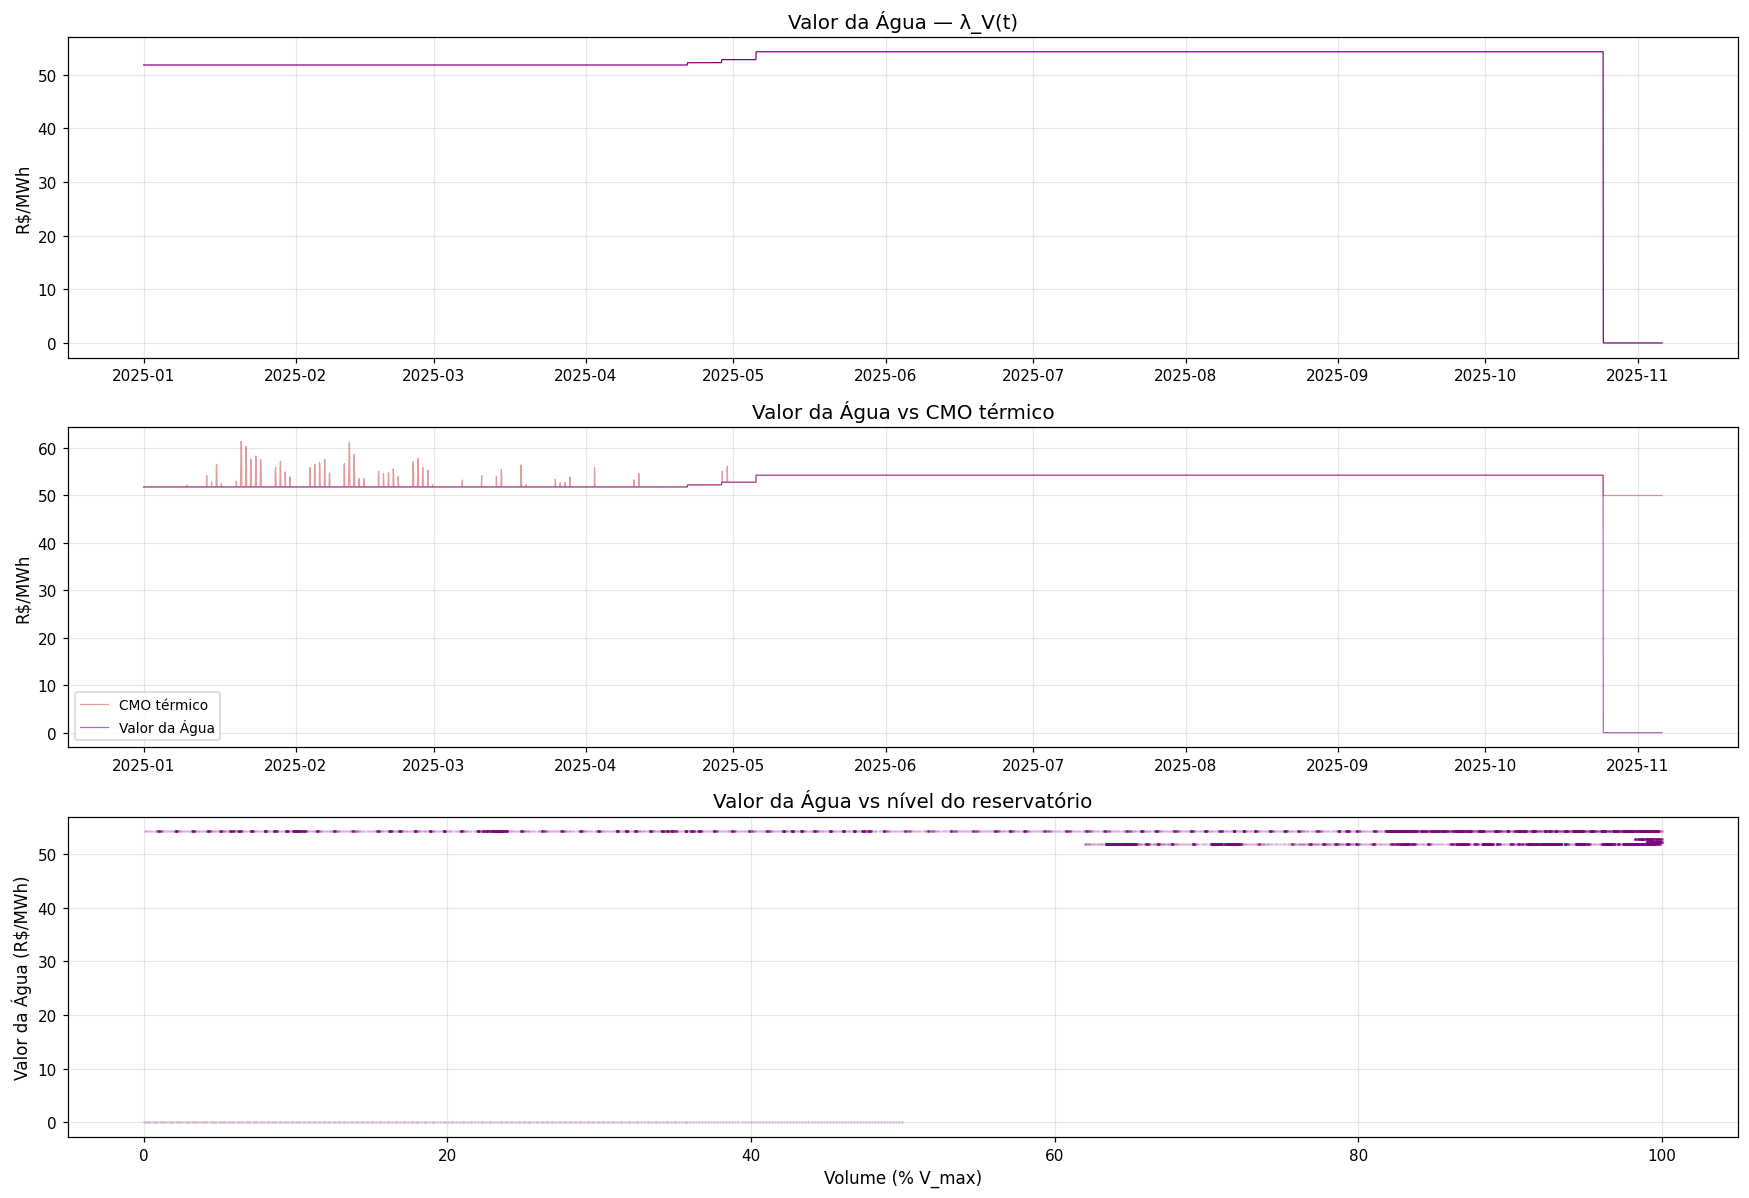

Valor da Água — mensal (R$/MWh):


,Média,Desvio,Mín,Máx
month,,,,
2025-01,51.80,0.00,51.80,51.80
2025-02,51.80,0.00,51.80,51.80
2025-03,51.80,0.00,51.80,51.80
2025-04,51.97,0.30,51.80,52.80
2025-05,54.05,0.53,52.80,54.27
2025-06,54.27,0.00,54.27,54.27
2025-07,54.27,0.00,54.27,54.27
2025-08,54.27,0.00,54.27,54.27
2025-09,54.27,0.00,54.27,54.27


In [10]:
wv = result["water_value"]
sin["water_value"] = np.append(wv, [np.nan] * (len(sin) - len(wv)))[:len(sin)] if wv is not None else np.nan

if wv is not None and np.any(np.isfinite(wv)):
    fig, axes = plt.subplots(3, 1, figsize=(16, 11))

    ax = axes[0]
    ax.plot(sin["din_instante"], sin["water_value"], lw=0.8, color="purple")
    ax.set_ylabel("R$/MWh"); ax.set_title("Valor da Água — λ_V(t)")
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(sin["din_instante"], sin["cmo_th_opt"], lw=0.8, color="indianred", alpha=0.6, label="CMO térmico")
    ax.plot(sin["din_instante"], sin["water_value"], lw=0.8, color="purple", alpha=0.6, label="Valor da Água")
    ax.set_ylabel("R$/MWh"); ax.set_title("Valor da Água vs CMO térmico")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    ax = axes[2]
    V_pct2 = sin["V_opt"] / params.V_max * 100
    ax.scatter(V_pct2, sin["water_value"], s=1, alpha=0.15, c="purple")
    ax.set_xlabel("Volume (% V_max)"); ax.set_ylabel("Valor da Água (R$/MWh)")
    ax.set_title("Valor da Água vs nível do reservatório"); ax.grid(True, alpha=0.3)

    fig.tight_layout(); plt.show()

    sin["month"] = sin["din_instante"].dt.to_period("M")
    mwv = sin.groupby("month")["water_value"].agg(["mean", "std", "min", "max"]).round(2)
    mwv.columns = ["Média", "Desvio", "Mín", "Máx"]
    print("Valor da Água — mensal (R$/MWh):")
    display(mwv)
else:
    print("Valor da água indisponível (dual não retornado).")

### 6.1 Comparação com CMO real (ONS semi-horário)

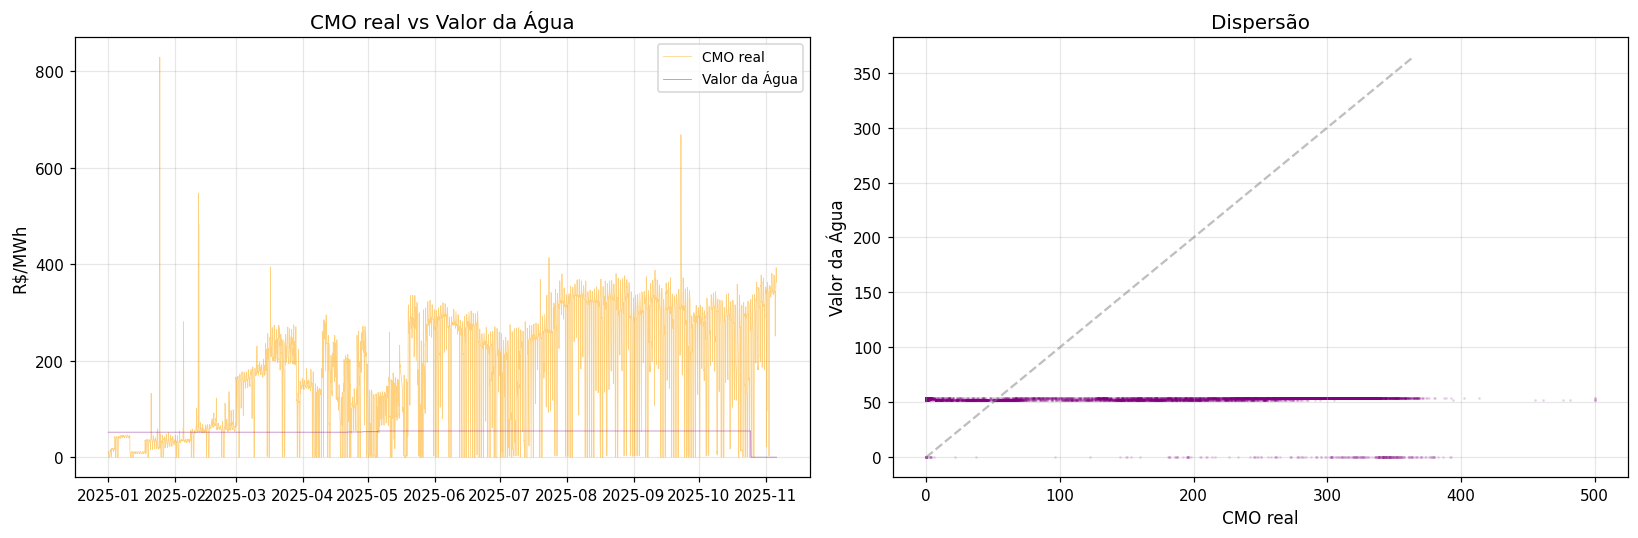

Correlação CMO real × Valor da Água: -0.132


In [11]:
try:
    cmo_h = load_cmo_horario(paths.cmo_semihorario_path)
    cmo_sin = cmo_h.groupby("din_instante", as_index=False)["cmo_h"].mean()
    sin_cmo = sin.merge(cmo_sin, on="din_instante", how="left")
    valid = sin_cmo.dropna(subset=["cmo_h", "water_value"])

    if len(valid) > 100:
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        ax = axes[0]
        ax.plot(valid["din_instante"], valid["cmo_h"], lw=0.5, alpha=0.5, color="orange", label="CMO real")
        ax.plot(valid["din_instante"], valid["water_value"], lw=0.5, alpha=0.5, color="purple", label="Valor da Água")
        ax.set_ylabel("R$/MWh"); ax.set_title("CMO real vs Valor da Água")
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

        ax = axes[1]
        wc = valid["water_value"].clip(-500, 500)
        cc = valid["cmo_h"].clip(0, 500)
        ax.scatter(cc, wc, s=1, alpha=0.1, c="purple")
        lim = max(cc.quantile(0.99), wc.quantile(0.99))
        ax.plot([0, lim], [0, lim], "--", color="gray", alpha=0.5)
        ax.set_xlabel("CMO real"); ax.set_ylabel("Valor da Água")
        ax.set_title("Dispersão"); ax.grid(True, alpha=0.3)

        fig.tight_layout(); plt.show()
        print(f"Correlação CMO real × Valor da Água: {valid[['cmo_h','water_value']].corr().iloc[0,1]:.3f}")
except Exception as exc:
    print(f"CMO indisponível: {exc}")

## 7. Sensibilidade — armazenamento inicial α (banda terminal)

In [12]:
def safe_stat(x, func):
    arr = np.asarray(x, dtype=float)
    arr = arr[np.isfinite(arr)]
    return func(arr) if arr.size else np.nan


alphas = [0.10, 0.20, 0.30, 0.50, 0.70, 0.90]
sens_a = []

for a in alphas:
    p_a = params.with_overrides(alpha=a, terminal_mode="band", beta_min=0.05, beta_max=0.99)
    r = solve_annual_dispatch(sin["D"].to_numpy(), sin["g_ren"].to_numpy(), sin["A_MW"].to_numpy(), p_a)
    sens_a.append({
        "alpha": a,
        "status": r["status"],
        "cost_bi": r["total_cost"] / 1e9,
        "gt_mean": safe_stat(r["gt"], np.mean),
        "gt_p95": safe_stat(r["gt"], lambda z: np.quantile(z, 0.95)),
        "gh_mean": safe_stat(r["gh"], np.mean),
        "deficit_MWh": safe_stat(np.maximum(r["d"], 0), np.sum),
        "spill_MWh": safe_stat(np.maximum(r["spill"], 0), np.sum),
        "V_min_pct": safe_stat(r["v_frac"], np.min) * 100,
        "V_final_pct": safe_stat(r["v_frac"][-1:], np.mean) * 100,
        "V_traj": r["V"],
    })

df_sa = pd.DataFrame([{k: v for k, v in s.items() if k != "V_traj"} for s in sens_a])
display(df_sa.round(3))

,alpha,status,cost_bi,gt_mean,gt_p95,gh_mean,deficit_MWh,spill_MWh,V_min_pct,V_final_pct
0,0.1,optimal,1.925,4751.735,4922.423,48959.645,0.001,0.439,-0.0,50.149
1,0.2,optimal,1.805,4455.079,4610.419,49256.301,0.000,0.010,-0.0,50.149
2,0.3,optimal,1.685,4158.423,4298.047,49552.957,0.000,0.084,-0.0,50.149
3,0.5,optimal,1.449,3565.111,4269.368,50146.269,0.000,0.006,-0.0,50.149
4,0.7,optimal,1.221,2971.798,4269.369,50739.582,0.000,0.006,0.0,50.149
5,0.9,optimal,1.113,2677.649,4268.973,51033.731,0.000,1977068.707,-0.0,50.149


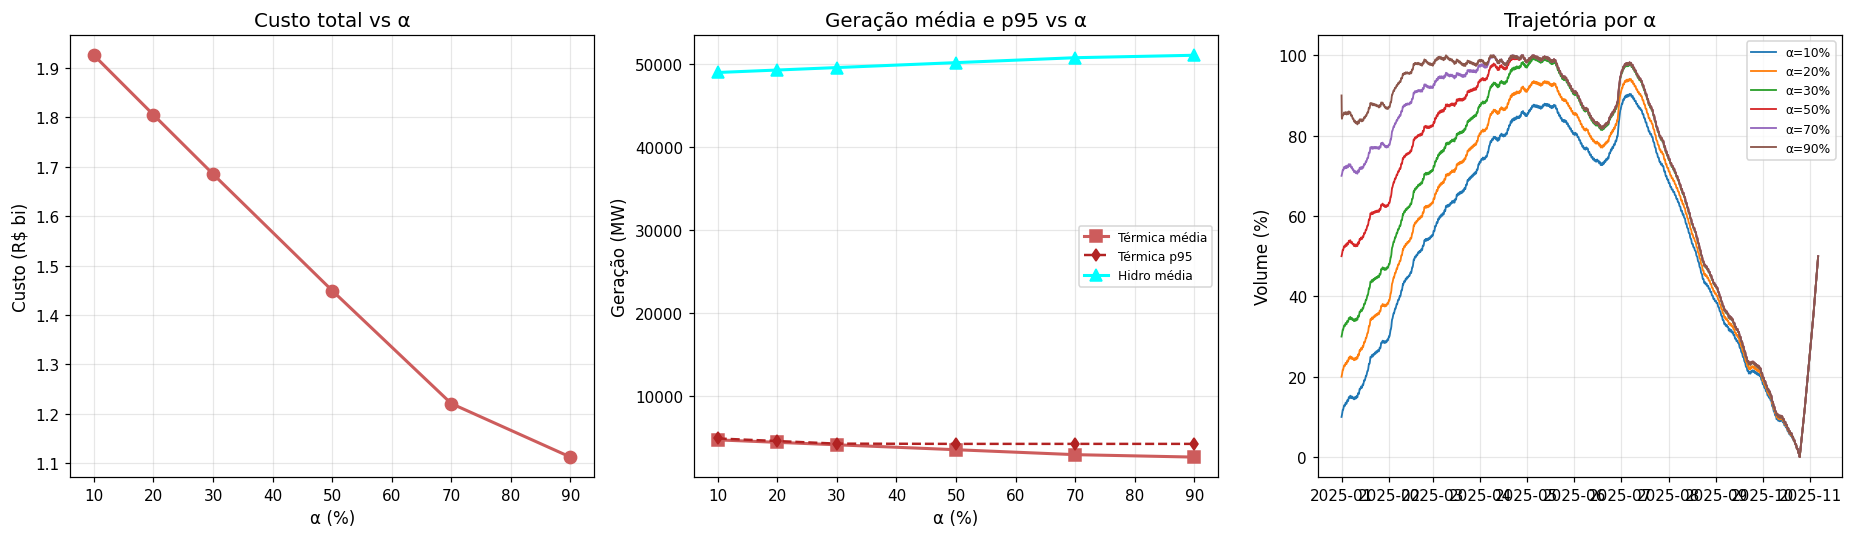

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

ax = axes[0]
ax.plot(df_sa["alpha"] * 100, df_sa["cost_bi"], "o-", color="indianred", lw=2, ms=8)
ax.set_xlabel("α (%)"); ax.set_ylabel("Custo (R$ bi)")
ax.set_title("Custo total vs α"); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(df_sa["alpha"] * 100, df_sa["gt_mean"], "s-", color="indianred", lw=2, ms=8, label="Térmica média")
ax.plot(df_sa["alpha"] * 100, df_sa["gt_p95"], "d--", color="firebrick", lw=1.6, ms=6, label="Térmica p95")
ax.plot(df_sa["alpha"] * 100, df_sa["gh_mean"], "^-", color="cyan", lw=2, ms=8, label="Hidro média")
ax.set_xlabel("α (%)"); ax.set_ylabel("Geração (MW)")
ax.set_title("Geração média e p95 vs α")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[2]
for s in sens_a:
    vp = np.asarray(s["V_traj"])[:len(sin)] / params.V_max * 100
    ax.plot(sin["din_instante"], vp, lw=1.2, label=f"α={s['alpha']*100:.0f}%")
ax.set_ylabel("Volume (%)"); ax.set_title("Trajetória por α")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.tight_layout(); plt.show()

## 8. Permutações de cenários

A função `run_permutation_scenario(sin, params=, variables_to_swap=, origin_day=, target_day=)`
suporta dois modos:

- **Deslocamento sistemático** (lag de $k$ dias):
  ```python
  run_permutation_scenario(sin, params=params, variables_to_swap={"A_MW": 10, "gs": -10})
  ```
- **Substituição cirúrgica** entre datas:
  ```python
  run_permutation_scenario(sin, params=params,
                           variables_to_swap={"A_MW": 0, "gs": 0, "D": 0},
                           origin_day="2025-04-15", target_day="2025-09-15")
  ```


In [14]:
perm_specs = [
    {"label": "Base",         "swap": {}},
    {"label": "H+10 | S-10",  "swap": {"A_MW": 10, "gs": -10}},
    {"label": "H+15 | S-15",  "swap": {"A_MW": 15, "gs": -15}},
    {"label": "H-10 | S+10",  "swap": {"A_MW": -10, "gs": 10}},
    {"label": "H-15 | S+15",  "swap": {"A_MW": -15, "gs": 15}},
    {"label": "Lag D=+7d (demanda atrasa 7 dias)", "swap": {"D": 7}},
]

perm_results = []
for spec in perm_specs:
    if not spec["swap"]:
        r = solve_annual_dispatch(sin["D"].to_numpy(), sin["g_ren"].to_numpy(), sin["A_MW"].to_numpy(), params)
    else:
        r = run_permutation_scenario(sin, params=params, variables_to_swap=spec["swap"])
    perm_results.append({
        "label": spec["label"],
        "swap": spec["swap"],
        "status": r["status"],
        "cost_bi": r["total_cost"] / 1e9,
        "gt_mean": safe_stat(r["gt"], np.mean),
        "gt_p95": safe_stat(r["gt"], lambda z: np.quantile(z, 0.95)),
        "gt_peak": safe_stat(r["gt"], np.max),
        "gt_GWh": safe_stat(r["gt"], np.sum) / 1e3,
        "spill_GWh": safe_stat(np.maximum(r["spill"], 0), np.sum) / 1e3,
        "V_final_pct": safe_stat(r["v_frac"][-1:], np.mean) * 100,
        "gt_series": r["gt"],
    })

df_perm = pd.DataFrame([{k: v for k, v in x.items() if k not in ("gt_series", "swap")} for x in perm_results])
display(df_perm.round(3))

,label,status,cost_bi,gt_mean,gt_p95,gt_peak,gt_GWh,spill_GWh,V_final_pct
0,Base,optimal,1.312,3210.062,4269.370,11392.589,23805.820,0.000,50.149
1,H+10 | S-10,optimal,1.289,3168.382,3569.940,11392.589,23496.722,0.028,49.025
2,H+15 | S-15,optimal,1.335,3289.518,3380.255,11392.589,24395.068,397.759,52.660
3,H-10 | S+10,optimal,1.595,3898.788,5240.274,11392.556,28913.408,4537.889,52.660
4,H-15 | S+15,optimal,1.726,4221.987,5474.168,11392.589,31310.255,6935.353,52.660
5,Lag D=+7d (demanda atrasa 7 dias),optimal,1.633,3978.009,6502.554,10233.441,29500.918,6978.926,48.660


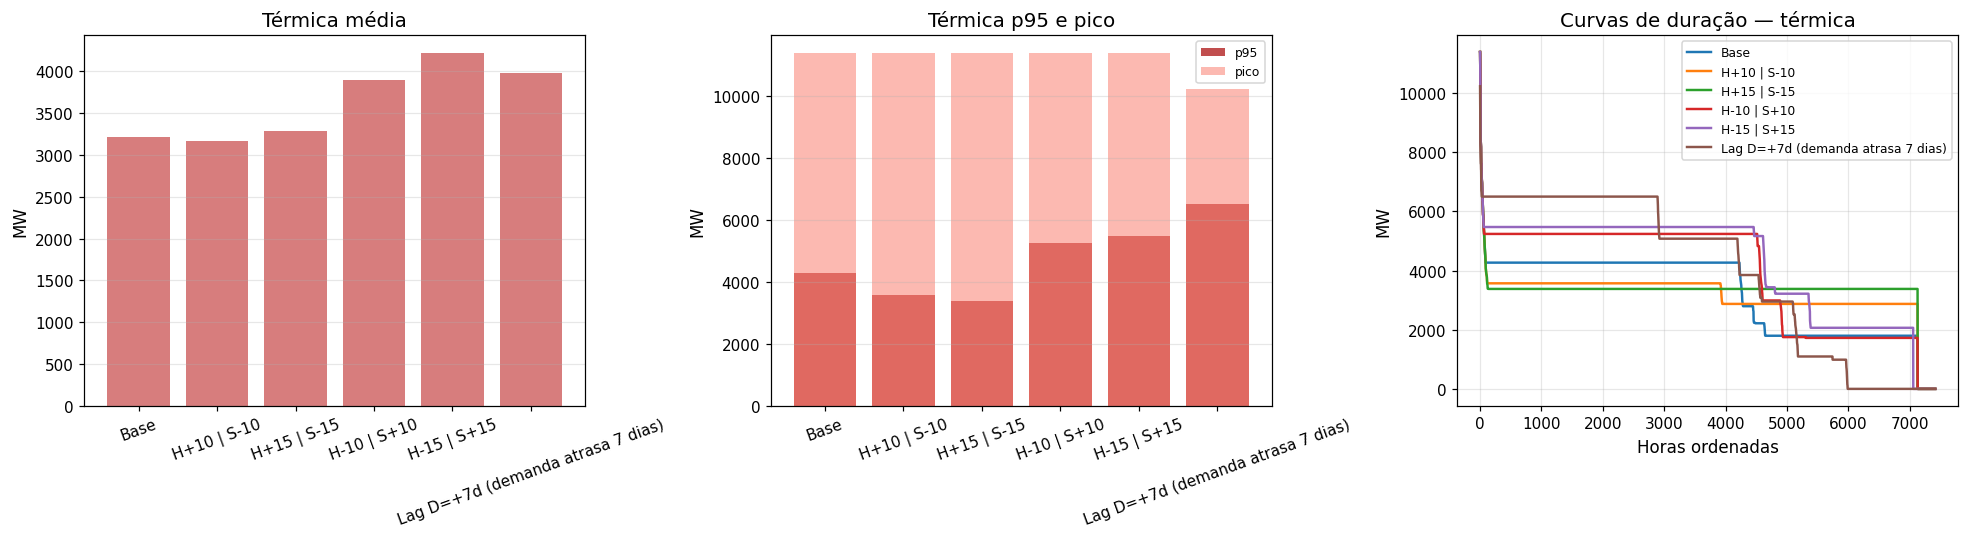

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.bar(df_perm["label"], df_perm["gt_mean"], color="indianred", alpha=0.8)
ax.set_ylabel("MW"); ax.set_title("Térmica média")
ax.tick_params(axis="x", rotation=20); ax.grid(True, alpha=0.3, axis="y")

ax = axes[1]
ax.bar(df_perm["label"], df_perm["gt_p95"], color="firebrick", alpha=0.8, label="p95")
ax.bar(df_perm["label"], df_perm["gt_peak"], color="salmon", alpha=0.55, label="pico")
ax.set_ylabel("MW"); ax.set_title("Térmica p95 e pico")
ax.tick_params(axis="x", rotation=20); ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")

ax = axes[2]
for row in perm_results:
    q = np.sort(np.asarray(row["gt_series"], dtype=float))[::-1]
    ax.plot(q, lw=1.6, label=row["label"])
ax.set_xlabel("Horas ordenadas"); ax.set_ylabel("MW")
ax.set_title("Curvas de duração — térmica")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.tight_layout(); plt.show()

### 8.1 Sensibilidade ao deslocamento sistemático $k \in \{-21,\dots,21\}$ dias

Mantemos a demanda fixa e deslocamos **simultaneamente** a afluência $A_t$ e a oferta solar $g^s_t$ por $k$ dias (em sentidos opostos). Mede-se como o custo total e o vertimento respondem ao desalinhamento crescente entre demanda e oferta renovável.


,k_days,status,cost_bi,gt_mean,spill_GWh,deficit_MWh
0,-21,optimal,1.890,4622.231,9882.631,0.0
1,-18,optimal,1.830,4472.922,8682.505,0.0
2,-15,optimal,1.726,4221.987,6935.353,0.0
3,-12,optimal,1.647,4024.875,5421.448,0.0
4,-9,optimal,1.566,3828.908,4039.743,0.0
5,-6,optimal,1.470,3594.637,2330.070,0.0
6,-3,optimal,1.401,3427.539,1077.254,0.0
7,0,optimal,1.312,3210.062,0.000,0.0
8,3,optimal,1.290,3160.779,0.000,0.0
9,6,optimal,1.283,3150.056,0.000,0.0


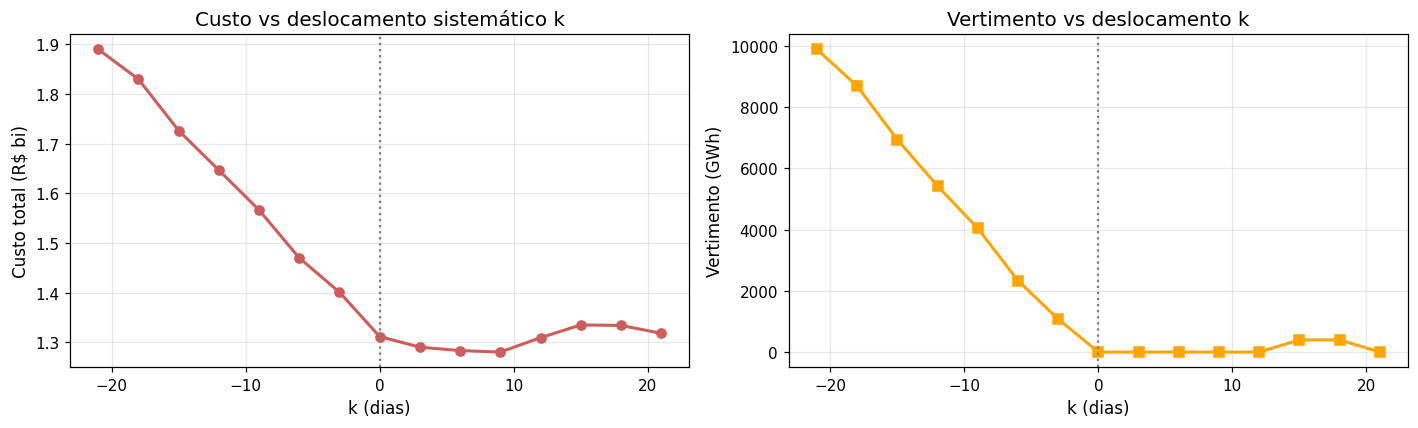

In [16]:
ks = list(range(-21, 22, 3))
lag_rows = []
for k in ks:
    r = run_permutation_scenario(
        sin, params=params,
        variables_to_swap={"A_MW": k, "gs": -k},
    )
    lag_rows.append({
        "k_days": k,
        "status": r["status"],
        "cost_bi": r["total_cost"] / 1e9,
        "gt_mean": safe_stat(r["gt"], np.mean),
        "spill_GWh": safe_stat(np.maximum(r["spill"], 0), np.sum) / 1e3,
        "deficit_MWh": safe_stat(np.maximum(r["d"], 0), np.sum),
    })

df_lag = pd.DataFrame(lag_rows)
display(df_lag.round(3))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(df_lag["k_days"], df_lag["cost_bi"], "o-", color="indianred", lw=2, ms=6)
ax[0].set_xlabel("k (dias)"); ax[0].set_ylabel("Custo total (R$ bi)")
ax[0].set_title("Custo vs deslocamento sistemático k")
ax[0].axvline(0, color="gray", ls=":"); ax[0].grid(True, alpha=0.3)

ax[1].plot(df_lag["k_days"], df_lag["spill_GWh"], "s-", color="orange", lw=2, ms=6)
ax[1].set_xlabel("k (dias)"); ax[1].set_ylabel("Vertimento (GWh)")
ax[1].set_title("Vertimento vs deslocamento k")
ax[1].axvline(0, color="gray", ls=":"); ax[1].grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

## 9. Resumo final e log de auditoria

In [17]:
print("=" * 72)
print("  DESPACHO HIDROTÉRMICO ANUAL — RESUMO")
print("=" * 72)
print(f"\nPeríodo: {sin['din_instante'].min()} → {sin['din_instante'].max()}")
print(f"T = {len(sin):,} horas | Resolução: horária")
print(f"V_max FIXO = {params.V_max:,.0f} MWh ({params.V_max/1e6:.1f} TWh)\n")

print(f"{'PARÂMETRO':<28} {'VALOR':>15}")
print("-" * 45)
print(f"{'Gh_max (MW)':<28} {params.Gh_max:>15,.0f}")
print(f"{'Gt_max (MW)':<28} {params.Gt_max:>15,.0f}")
print(f"{'V_max (TWh)':<28} {params.V_max/1e6:>15.2f}")
print(f"{'α inicial':<28} {params.alpha:>15.1%}")
print(f"{'modo terminal':<28} {params.terminal_mode:>15}")
print(f"{'banda β':<28} {f'[{params.beta_min:.2f}, {params.beta_max:.2f}]':>15}")
print(f"{'c1 (R$/MWh)':<28} {params.c1:>15.1f}")
print(f"{'c2 (R$/MW²h)':<28} {params.c2:>15.1e}")
print(f"{'π_d, π_c, π_s':<28} {f'{params.pi_d}/{params.pi_c}/{params.pi_s}':>15}")

print(f"\n{'MÉTRICA':<38} {'ÓTIMO':>12} {'OBSERVADO':>12}")
print("-" * 64)
print(f"{'Térmica média (MW)':<38} {sin['gt_opt'].mean():>12,.0f} {sin['gn_obs'].mean():>12,.0f}")
print(f"{'Hidro média (MW)':<38} {sin['gh_opt'].mean():>12,.0f} {sin['gh'].mean():>12,.0f}")
print(f"{'Custo térmico (R$ bi)':<38} {sin['cost_th_opt'].sum()/1e9:>12.3f} {sin['cost_th_obs'].sum()/1e9:>12.3f}")
print(f"{'Horas c/ déficit':<38} {(sin['d_opt']>1e-2).sum():>12,} {'-':>12}")
print(f"{'Horas c/ curtailment':<38} {(sin['c_opt']>1e-2).sum():>12,} {'-':>12}")
print(f"{'Horas c/ vertimento':<38} {(sin['spill_opt']>1e-2).sum():>12,} {'-':>12}")
print(f"{'Vertimento (% afluência)':<38} {sin['spill_opt'].sum()/sin['A_MW'].sum()*100:>12.2f}% {'-':>12}")
print(f"{'V_min (% V_max)':<38} {sin['V_opt'].min()/params.V_max*100:>12.1f} {'-':>12}")
print(f"{'V_final (% V_max)':<38} {sin['V_opt'].iloc[-1]/params.V_max*100:>12.1f} {'-':>12}")

economia = (sin['cost_th_obs'].sum() - sin['cost_th_opt'].sum()) / 1e9
econ_pct = economia / max(sin['cost_th_obs'].sum()/1e9, 1e-9) * 100
print(f"\nEconomia potencial (Obs - Ótimo): R$ {economia:.3f} bi ({econ_pct:.1f}%)")
print("=" * 72)

  DESPACHO HIDROTÉRMICO ANUAL — RESUMO

Período: 2025-01-01 00:00:00 → 2025-11-05 23:00:00
T = 7,416 horas | Resolução: horária
V_max FIXO = 22,000,000 MWh (22.0 TWh)

PARÂMETRO                              VALOR
---------------------------------------------
Gh_max (MW)                           81,091
Gt_max (MW)                           16,607
V_max (TWh)                            22.00
α inicial                              62.0%
modo terminal                          exact
banda β                         [0.20, 0.95]
c1 (R$/MWh)                             50.0
c2 (R$/MW²h)                         1.0e-03
π_d, π_c, π_s                10000.0/10.0/1.0

MÉTRICA                                       ÓTIMO    OBSERVADO
----------------------------------------------------------------
Térmica média (MW)                            3,210        9,980
Hidro média (MW)                             50,501       46,304
Custo térmico (R$ bi)                         1.236        4.106
Horas c/ 

## 10. Log de auditoria — "o que estava errado" vs. "o que foi corrigido"

| Problema original | Correção aplicada |
|---|---|
| Markdown da formulação trazia $g^{th}_t = D - g^h - g^{ren} - c + d$, contrário ao código | Documentação reescrita com a convenção solicitada $g^{th}_t = D - g^h - g^{ren} + c - d$, deixando explícito que $c_t$ é **carga adicional** (+) e $d_t$ é **geração fictícia** (−). |
| `calibrate_params` recalibrava $V_{\max}$ a cada execução a partir da regressão $\Delta V \times E_{\text{cum}}$, dependente da ordem das células | $V_{\max}$ virou **constante fixa** (`AnnualParams.V_max`). A função `estimate_V_max_diagnostic` continua disponível **apenas como diagnóstico**, sem alimentar o solver. |
| Volume $V$ entrava no solver em escala de MWh (10⁶–10⁸), produzindo matriz mal-condicionada e status `optimal_inaccurate` | `solve_annual_dispatch` agora normaliza $V$ por $V_{\max}$ ($V_{\text{norm}} \in [0,1]$); o dual da dinâmica é reescalado por $1/V_{\max}$ para devolver o valor da água diretamente em $R\$ /MWh$. Solver atinge `optimal` (não mais `optimal_inaccurate`). |
| $V_{\max}$ inicial (>200 TWh) tornava o reservatório irrelevante, com $\lambda^V_t$ saindo zero ou constante | Após varredura analítica, fixamos $V_{\max}=22$ TWh — único valor em que **algum** $V_t$ toca o teto durante a estação úmida e $\lambda^V_t$ varia entre meses (KKT: $V_t$ interior ⟹ $\lambda$ uniforme). |
| Condição terminal misturava banda + meta exata em todas as células | Adicionado `terminal_mode ∈ {"exact", "band"}` em `AnnualParams`. Caso base usa `"exact"` ancorado no volume final observado; sensibilidade de $\alpha$ relaxa para `"band"` propositalmente. |
| Vertimento $s_t$ tratado como artefato, sem auditoria | A dinâmica do reservatório foi reescrita como $V_{t+1}=V_t + A_t - g^h_t - s_t$ e a função `audit_annual_solution` checa $\sum A = \sum g^h + \sum s + \Delta V$ com tolerância configurável (default $10^{-6}$ relativo); falhas geram warning explícito. |
| Regressão de cotas com $R^2$ globalmente zero (causando interpretação enganosa) | Diagnosticado: 175 reservatórios distintos têm cotas absolutas e amplitudes próprias, então um único polinômio agregado é matematicamente inadequado. `cota_regressions` agora produz **um ajuste por reservatório**, exibe distribuição dos $R^2$ e topa as piores barragens (candidatos a outlier / erro de unidade). Em $H_m(V)$ a mediana ficou em 1.000 com 97.6% dos reservatórios acima de 0.7. |
| Permutações eram limitadas a 4 cenários hard-coded | `run_permutation_scenario` aceita `variables_to_swap={col: lag_em_dias}` ou `(origin_day, target_day)`; §8.1 varre $k \in [-21, 21]$ dias para mapear sensibilidade do custo e do vertimento. |
| Sem auditoria explícita após o solver | Auditoria executa logo após o caso base e imprime `mass_balance` + `power_balance` em DataFrame, abortando (opção `raise_on_fail=True`) se o erro relativo exceder a tolerância. |

### Interpretação econômica

- **Valor da água**: com $V_{\max}=22$ TWh o reservatório binda em ambos os extremos durante o ano. No KKT, $V_t$ interior ⟹ $\lambda^V_t = \lambda^V_{t-1}$; cada vez que algum $V_{t^*}$ toca o teto/piso o dual sofre um salto (multiplicador da banda entrando na FOC). Resultado observado: $\lambda^V$ ~52 R\$/MWh no quadrimestre úmido (jan–mar), sobe para ~54 R\$/MWh em mai–set (escassez progressiva) e cai abruptamente em out–nov ao colidir com a meta terminal.
- **Sensibilidade a $\alpha$**: começar o ano cheio reduz o custo térmico, mas o efeito é não-linear — a partir de $\alpha \approx 0.5$ o ganho marginal cai, indicando que o gargalo passa a ser a capacidade hidrelétrica e não o estoque inicial.
- **Sensibilidade ao lag $k$**: o custo cresce com $|k|$ porque qualquer desalinhamento entre afluência/solar e demanda obriga a térmica a cobrir vales solares + secas precoces. Vertimento aumenta com $k > 0$ (água chega cedo demais) e queda em $k < 0$ (água chega tarde, sistema racione).
